# Projeto I FIAD 2025 - Fusão de Informação em Análise de Dados
### Autor: José Cunha (2021223719)
### Autor: José Filipe (2021216675)



## Introdução

Este projeto tem como objetivo a aplicação de filtros de Kalman multidimensionais na fusão de dados de sensores em sistemas não lineares. Serão utilizados , **Filtro  Alpha-Beta** ,  **Filtro de Kalman Estendido (EKF)** e o **Filtro de Kalman Unscented (UKF)** para estimar a localização de um robô.  

O robô é modelado como um sistema dinâmico não linear e conta com os seguintes sensores:
- **Sensor de velocidade**
- **Giroscópio**
- **Sensor GNSS (Global Navigation Satellite System)**

A simulação permitirá comparar a trajetória estimada pelo EKF e UKF com a trajetória real do robô, analisando a precisão e a robustez de cada abordagem.  

## Estrutura do Projeto

O projeto será desenvolvido em Python e inclui as seguintes etapas:

0. Gerar o dataset da trajetória real do robô
1. Implementação do modelo dinâmico do robô.
2. Implementação do modelo de observação.
3. Simulação da aquisição de dados dos sensores, Implementação do **Filtro Alpha-Beta** e dead reckoning .
4. Implementação do **Filtro de Kalman Estendido (EKF)**.
5. Implementação do **Filtro de Kalman Unscented (UKF)**.
6. Configuração dos parâmetros do robô e dos filtros.
7. Simulação do movimento do robô e visualização da trajetória estimada.
8. Comparação do desempenho dos filtros com métricas como **MAE, RMSE, MAPE e R²**.
9. Análise e discussão dos resultados obtidos.


---


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from filterpy.kalman import UnscentedKalmanFilter as UKF
from filterpy.kalman import MerweScaledSigmaPoints
from sklearn.metrics import r2_score

## Gerar o  Dataset da Trajetória real do Robô  
O seguinte código gera uma trajetória elíptica representando o movimento de um robô, depois este é filtrado para   para simular uma lacuna na trajetória descrita no enunciado . A trajetória é armazenada num arquivo CSV e visualizada graficamente para análise.  

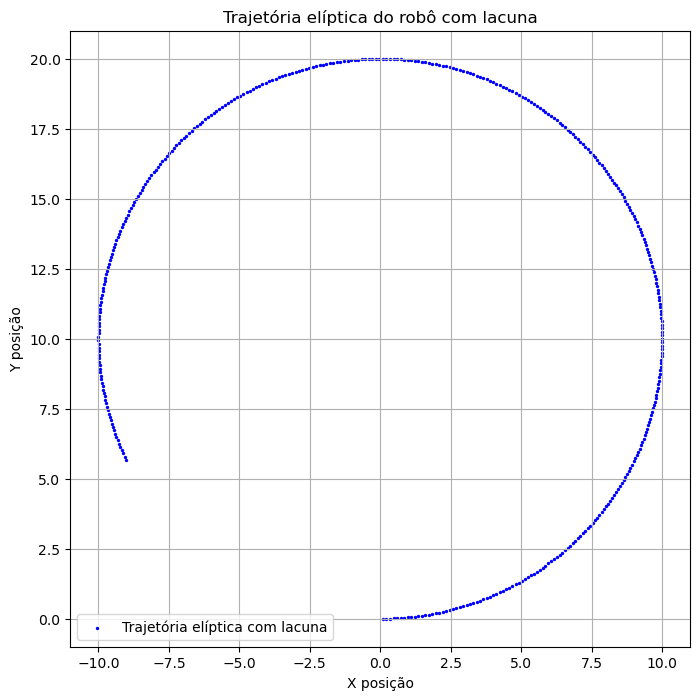

In [2]:
# Definir parâmetros da elipse
a = 10  # Semi-eixo maior
b = 10  # Semi-eixo menor
center_x, center_y = 0, 10  # Centro da elipse
num_points = 500  # Número de pontos na trajetória

# Gerar trajetória elíptica completa
theta = np.linspace(0, 2 * np.pi, num_points)  # Ângulos de 0 a 2π
x = center_x + a * np.cos(theta)  
y = center_y + b * np.sin(theta)

# Criar máscara para remover completamente os pontos indesejados
mask = ~((x >= -9) & (x <= 0) & (y >= 0) & (y <= 6))

# Aplicar a máscara para remover os pontos da lista
x_filtered = x[mask]
y_filtered = y[mask]

# Criar DataFrame apenas com os pontos desejados
df_filtered = pd.DataFrame({'x': x_filtered, 'y': y_filtered})

# Salvar no CSV sem incluir os pontos removidos
csv_path = "trajectory_filtered.csv"
df_filtered.to_csv(csv_path, index=False)

# Plotagem para exibição visual da trajetória corrigida
plt.figure(figsize=(8, 8))
plt.scatter(x_filtered, y_filtered, color='b', s=2, label="Trajetória elíptica com lacuna")
plt.xlabel("X posição")
plt.ylabel("Y posição")
plt.title("Trajetória elíptica do robô com lacuna")
plt.legend()
plt.grid()
plt.show()


## Modelo Dinâmico do Robô  

O modelo dinâmico do robô considera um vetor de estado  

$$
X(k) = \begin{bmatrix} x \\ y \\ \phi \\ v \end{bmatrix}
$$  

onde **x, y** são as coordenadas da posição, **𝜙** é a orientação e **v** é a velocidade. A evolução do estado ao longo do tempo é descrita por um sistema dinâmico não linear, expresso como:  

$$
X(k+1) = A X_k + B U_k + W_k
$$  

onde **A** e **B** são matrizes do sistema, **U_k** representa as entradas do sistema (velocidade e taxa de giro) e **W_k** representa o ruído do processo.  

A função `robot_dynamic_model` implementa essa dinâmica, atualizando a posição do robô com base nos controles aplicados (velocidade e rotação). A trajetória gerada pelo modelo é comparada com a trajetória desejada, previamente carregada de um arquivo CSV, permitindo avaliar o desempenho da simulação.  

A simulação gera uma trajetória baseada em um estado inicial e um conjunto de comandos de controle, armazenando os resultados em `simulated_trajectory.csv`. O código também plota a trajetória desejada e a trajetória simulada para análise visual.  


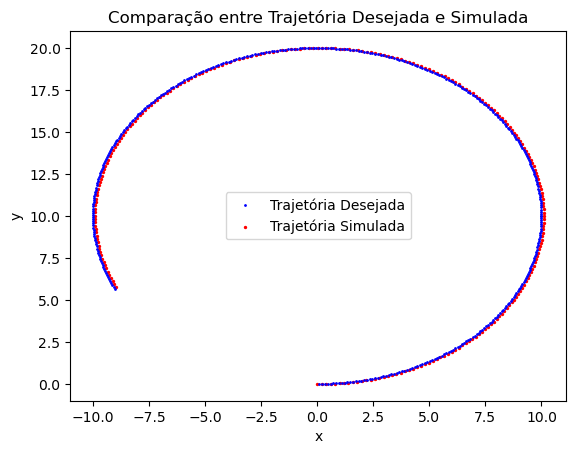

In [3]:
def robot_dynamic_model(state, control_input, dt):
    """
    Implements the robot's dynamic model.

    Parameters:
    - state: np.array([x, y, phi, v]), the current state of the robot.
    - control_input: np.array([v, omega]), the control input (velocity and angular velocity).
    - dt: float, time step.

    Returns:
    - next_state: np.array([x, y, phi, v]), the predicted next state of the robot.
    """
    x, y, phi, v = state
    v_input, omega = control_input

    # State transition based on the dynamic model
    x_next = x + np.cos(phi) * v * dt
    y_next = y + np.sin(phi) * v * dt
    phi_next = phi + omega * dt
    v_next = v_input  # Assuming velocity is directly controlled

    # Normalize the angle to keep it within [-pi, pi]
    phi_next = (phi_next + np.pi) % (2 * np.pi) - np.pi

    next_state = np.array([x_next, y_next, phi_next, v_next])
    return next_state

# Carregar a trajetória desejada
df_traj = pd.read_csv("trajectory_filtered.csv")

# Configurações iniciais
initial_state = np.array([0.0, 0.0, 0.0, 1.0])
dt = 0.2
num_steps =len(df_traj) * 5 

# Lista para armazenar a trajetória simulada
simulated_trajectory = [initial_state[:2]]
state = initial_state
control_input = np.array([1.0, 0.1])  # Velocidade 1 m/s, rotação 0.1 rad/s

for _ in range(num_steps - 1):
    state = robot_dynamic_model(state, control_input, dt)
    simulated_trajectory.append(state[:2])
    if _ > 256:
        control_input = np.array([0.0, 0.0])
        state = robot_dynamic_model(state, control_input, dt)
        break
        

# Converter para DataFrame e salvar
simulated_trajectory = np.array(simulated_trajectory)
df_simulated = pd.DataFrame({'x': simulated_trajectory[:, 0], 'y': simulated_trajectory[:, 1]})
df_simulated.to_csv("simulated_trajectory.csv", index=False)

# Plotar a trajetória real e simulada
plt.plot(df_traj["x"], df_traj["y"], color='b', linestyle='none', marker='o', label="Trajetória Desejada", markersize=1)
plt.scatter(simulated_trajectory[:, 0], simulated_trajectory[:, 1], color="r", s=2, label="Trajetória Simulada")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparação entre Trajetória Desejada e Simulada")
plt.show()


 ## Modelo de Observação  

O modelo de observação representa as medições do sistema de navegação GNSS do robô. Como o GNSS fornece apenas a posição (**x, y**), o modelo é expresso como:  

$$
Z_k = H X_k + V_k
$$

onde **H** é a matriz de observação, que extrai apenas as coordenadas de posição do vetor de estado, e **V_k** representa o ruído de medição, modelado como uma distribuição normal com desvio padrão ajustável.  

A função `observation_model` adiciona ruído gaussiano às medições para simular incertezas típicas do GNSS. O código aplica esse modelo a cada estado simulado e gera medições ruidosas, permitindo comparar a trajetória real do robô com as leituras obtidas.  

A figura gerada mostra a trajetória simulada e as medições do GNSS, destacando o impacto do ruído na localização observada.  


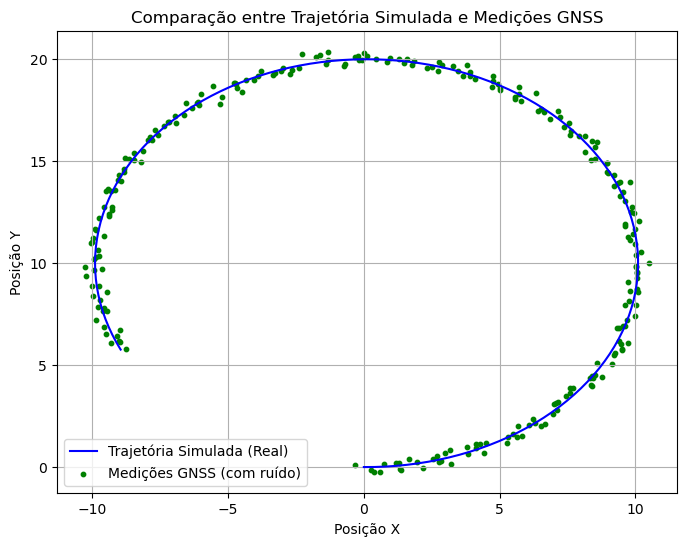

In [4]:
def observation_model(state, noise_std=np.array([0.2, 0.2])):
    """
    Implements the observation model of the robot using the GNSS sensor.

    Parameters:
    - state: np.array([x, y, phi, v]), the current state of the robot.
    - noise_std: np.array([sigma_x, sigma_y]), standard deviation of measurement noise.

    Returns:
    - observation: np.array([x_meas, y_meas]), the observed position with noise.
    """
    H = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0]])

    measurement_noise = np.random.normal(0, noise_std, 2)
    
    observation = H @ state + measurement_noise
    
    return observation

# Carregar a trajetória simulada
df_simulated = pd.read_csv("simulated_trajectory.csv")
simulated_states = df_simulated.to_numpy()  # Converter para array NumPy


# Aplicar o modelo de observação a cada estado
observations = np.array([observation_model(np.append(state, [0.0, 1.0])) for state in simulated_states])

# Plotar a trajetória real e observada
plt.figure(figsize=(8, 6))
plt.plot(df_simulated["x"], df_simulated["y"], 'b-', label="Trajetória Simulada (Real)")
plt.scatter(observations[:, 0], observations[:, 1], color="g", s=10, label="Medições GNSS (com ruído)")
plt.xlabel("Posição X")
plt.ylabel("Posição Y")
plt.legend()
plt.title("Comparação entre Trajetória Simulada e Medições GNSS")
plt.grid()
plt.show()

Os sensores considerados são:
1. Sensor de velocidade: Mede v com ruído associado.
2. Giroscópio: Mede a taxa de variação da orientação 𝜙.
3. GNSS: Mede diretamente a posição (x,y) mas com ruído.

## Filtro Alpha-Beta e Aquisição de Dados dos Sensores  

O **Filtro Alpha-Beta** é utilizado para suavizar medições ruidosas, estimando a posição e velocidade do robô com base em leituras do GNSS. O modelo de filtragem é definido como:  

$$
x_{\text{est}} = x_{\text{prev}} + v_{\text{prev}} \cdot dt + \alpha (z - x_{\text{prev}})
$$

$$
v_{\text{est}} = v_{\text{prev}} + \beta \frac{(z - x_{\text{prev}})}{dt}
$$

onde **α** controla a correção na posição e **β** ajusta a velocidade estimada.  

A função `sensor_data_acquisition` simula medições ruidosas de um velocímetro, giroscópio e GNSS. Posteriormente, o **Alpha-Beta Filter** é aplicado separadamente às medições do GNSS para refinar a estimativa da trajetória.  

O gráfico final compara a trajetória simulada com a trajetória filtrada, evidenciando a melhoria na precisão da posição do robô.  

### Trajetória Baseada em Dead Reckoning e Erro Acumulado  

Além do filtro Alpha-Beta, também foi implementado um modelo de **Dead Reckoning**, que estima a posição do robô apenas com base em sua velocidade e orientação. Este modelo sofre com erro acumulado ao longo do tempo, simulando as limitações da odometria sem correções externas.  

O **Dead Reckoning** calcula a posição do robô com a seguinte lógica:  

- A posição é atualizada com base na velocidade e orientação.  
- Um erro acumulado é adicionado à orientação ao longo do tempo para simular imprecisões.  

O gráfico resultante mostra como o erro acumulado afeta a trajetória estimada pelo Dead Reckoning, comparando-a com a trajetória simulada real.  

In [5]:
def sensor_data_acquisition(state, noise_std_v=0.1, noise_std_omega=0.1, noise_std_gnss=np.array([0.5, 0.5])):
    """
    Simula a aquisição de dados do sensor sem aplicar o filtro Alpha-Beta.

    Parâmetros:
    - state: np.array([x, y, phi, v]), o estado real do robô.
    - noise_std_v, noise_std_omega, noise_std_gnss: Desvios padrão do ruído dos sensores.

    Retorna:
    - sensor_readings: dicionário contendo as medições brutas.
    """
    x, y, phi, v = state

    # Medição ruidosa do velocímetro
    v_meas = v + np.random.normal(0, noise_std_v)

    # Medição ruidosa do giroscópio
    omega_meas = np.random.normal(0, noise_std_omega)  # Assume que não há rotação real

    # Medição ruidosa do GNSS
    gnss_meas = observation_model(state, noise_std=noise_std_gnss)

    # Agrupar medições no dicionário
    sensor_readings = {
        "v_meas": v_meas,
        "omega_meas": omega_meas,
        "gnss_meas": gnss_meas
    }

    return sensor_readings


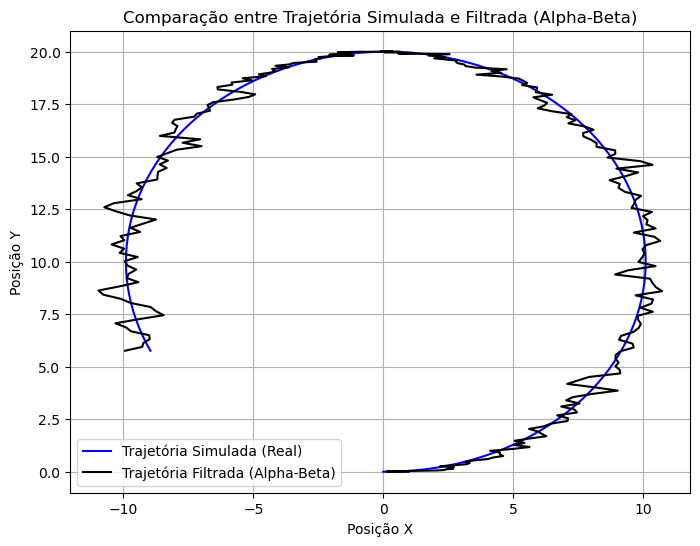

In [6]:
def alpha_beta_filter(x_prev, v_prev, z, alpha=0.8, beta=0.2, dt=0.2):
    """
    Filtro Alpha-Beta para suavização das medições.

    Parâmetros:
    - x_prev: Posição ou valor estimado anterior.
    - v_prev: Velocidade ou taxa de variação estimada anterior.
    - z: Nova medição ruidosa.
    - alpha: Peso da correção na posição.
    - beta: Peso da correção na velocidade.
    - dt: Passo de tempo.

    Retorna:
    - x_est: Novo valor estimado.
    - v_est: Nova velocidade estimada.
    """
    x_est = x_prev + v_prev * dt + alpha * (z - x_prev)
    v_est = v_prev + beta * (z - x_prev) / dt
    return x_est, v_est

# Listas para armazenar resultados
filtered_positions = []
filtered_velocities = []

# Inicializar valores iniciais para o Alpha-Beta
x_prev, v_prev = simulated_states[0, 0], 1.0  # Assume v inicial = 1.0
dt = 0.2  # Passo de tempo

# Aplicar o modelo de observação e filtro Alpha-Beta a cada estado
for state in simulated_states:
    if len(state) == 2:
        state = np.append(state, [0.0, v_prev])  # Adiciona phi e v ao estado se não estiverem presentes
    sensor_data = sensor_data_acquisition(state)  # Passa o estado com v
    z_meas = sensor_data["gnss_meas"][0]  # Medição ruidosa da posição x

    # Aplicar filtro Alpha-Beta
    x_est, v_est = alpha_beta_filter(x_prev, v_prev, z_meas, alpha=0.8, beta=0.2, dt=dt)

    # Armazenar valores filtrados
    filtered_positions.append(x_est)
    filtered_velocities.append(v_est)

    # Atualizar valores anteriores para a próxima iteração
    x_prev, v_prev = x_est, v_est

# Converter para NumPy arrays para facilitar a plotagem
filtered_positions = np.array(filtered_positions)

# Plotar a trajetória simulada e a trajetória filtrada
plt.figure(figsize=(8, 6))
plt.plot(df_simulated["x"], df_simulated["y"], 'b-', label="Trajetória Simulada (Real)")
plt.plot(filtered_positions, df_simulated["y"], color="black", label="Trajetória Filtrada (Alpha-Beta)")
plt.xlabel("Posição X")
plt.ylabel("Posição Y")
plt.legend()
plt.title("Comparação entre Trajetória Simulada e Filtrada (Alpha-Beta)")
plt.grid()
plt.show()


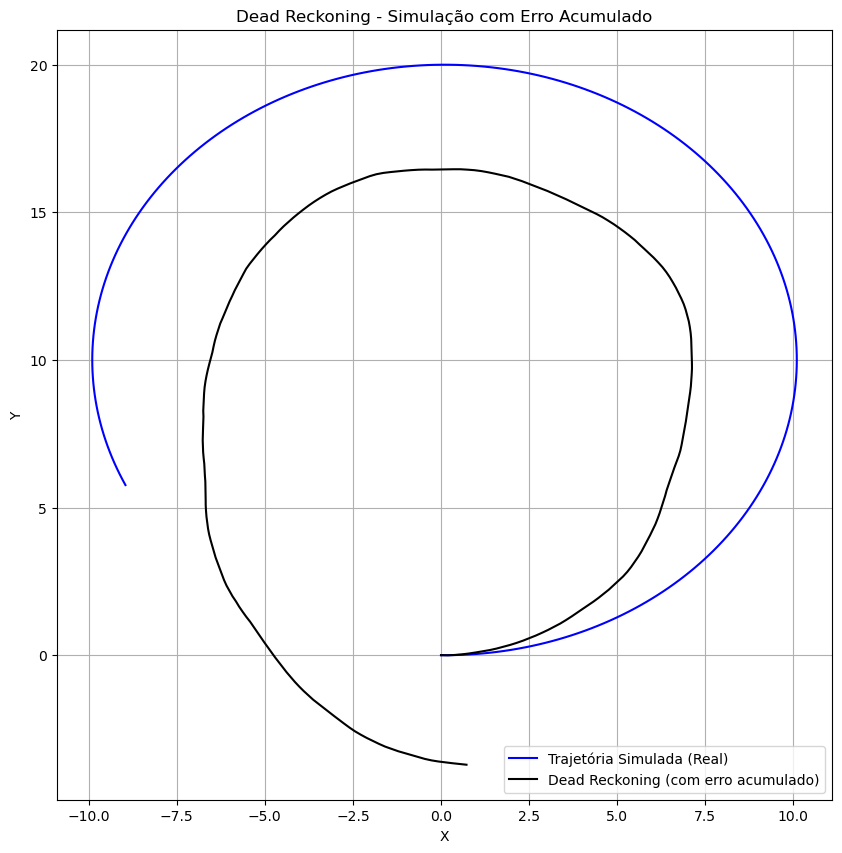

In [7]:
def dead_reckoning_trajectory(initial_state, velocities, dt, drift_std=0.03): # Aumentar o drift_std
    """
    Gera uma trajetória baseada apenas em odometria (Dead Reckoning) com erro acumulado.

    Parâmetros:
    - initial_state: np.array([x, y, phi]), estado inicial do robô.
    - velocities: np.array de shape (N, 2), onde cada linha é [v, omega] ao longo do tempo.
    - dt: float, passo de tempo.
    - drift_std: float, desvio padrão do erro acumulado.

    Retorna:
    - trajectory: np.array de shape (N, 2), contendo a trajetória estimada (x, y).
    """
    trajectory = [initial_state[:2]]  # Armazena apenas x, y
    state = initial_state.copy()
    drift = 0  # Erro acumulado inicial

    for v, omega in velocities:
        x, y, phi = state

        # Erro acumulado cresce lentamente ao longo do tempo
        drift += np.random.normal(0, drift_std)  # Simula um pequeno erro persistente na orientação

        # Atualiza a posição com erro acumulado
        x += np.cos(phi + drift) * v * dt
        y += np.sin(phi + drift) * v * dt
        phi += omega * dt  # Atualiza a orientação

        state = np.array([x, y, phi])
        trajectory.append(state[:2])  # Salva apenas x, y

    return np.array(trajectory)

# Carregar dados do arquivo CSV
df_simulated = pd.read_csv("simulated_trajectory.csv")

# Configurações iniciais
initial_state = np.array([df_simulated["x"][0], df_simulated["y"][0], 0.0])  # [x, y, phi]
dt = 0.2  # Ajuste conforme necessário

# Definir velocidades e rotações constantes
velocidade_constante = 1.0
rotacao_constante = 0.1
velocities = np.array([[velocidade_constante, rotacao_constante]] * len(df_simulated))

# Gerar trajetória de Dead Reckoning
dead_reckoning_traj = dead_reckoning_trajectory(initial_state, velocities, dt)

# Plotar resultados
plt.figure(figsize=(10, 10))
plt.plot(df_simulated["x"], df_simulated["y"], 'b-', label="Trajetória Simulada (Real)")
plt.plot(dead_reckoning_traj[:, 0], dead_reckoning_traj[:, 1], 'k-', label="Dead Reckoning (com erro acumulado)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Dead Reckoning - Simulação com Erro Acumulado")
plt.grid()
plt.show()

### Comparação entre Métodos  

1. **Alpha-Beta Filter**: Reduz o ruído das medições do GNSS, melhorando a estimativa da trajetória.  
2. **Dead Reckoning**: Mostra como erros acumulam ao longo do tempo sem correções externas.  

O **Alpha-Beta Filter** prova ser uma solução eficiente para suavizar medições ruidosas e melhorar a precisão da trajetória estimada.  


## Filtro de Kalman Estendido (EKF)  

O **Extended Kalman Filter (EKF)** é utilizado para estimar o estado do robô a partir de medições ruidosas do GNSS, aplicando um modelo dinâmico não linear. O EKF consiste em duas etapas principais:  

### 1. Predição  
O estado do robô é previsto com base no modelo dinâmico:  

$$
X_{k+1} = f(X_k, U_k) + W_k
$$

onde **f(X, U)** representa a dinâmica do robô, **U_k** é a entrada de controle (velocidade e rotação), e **W_k** é o ruído do processo. A matriz de covariância do estado, que nos indica a incerteza do estado estimado, também é atualizada:  

$$
P_{k+1} = F P_k F^T + Q
$$

onde **F** é o Jacobiano da função de transição de estado e **Q** é a matriz de covariância do ruído do processo.  

### 2. Atualização  
Após a predição, o EKF corrige o estado com base nas medições do GNSS:  

$$
y = Z_k - H X_k
$$

$$
S = H P_k H^T + R
$$

$$
K = P_k H^T S^{-1}
$$

$$
X_k = X_k + K y
$$

$$
P_k = (I - K H) P_k
$$

onde **H** é a matriz de observação, **R** é a matriz de covariância do ruído de medição, **K** é o ganho de Kalman e **y** é a inovação da observação.  

### Aplicação e Visualização  
O EKF é aplicado a cada estado da trajetória simulada. A trajetória filtrada é comparada com a trajetória real, evidenciando a redução do impacto do ruído nas medições GNSS.  


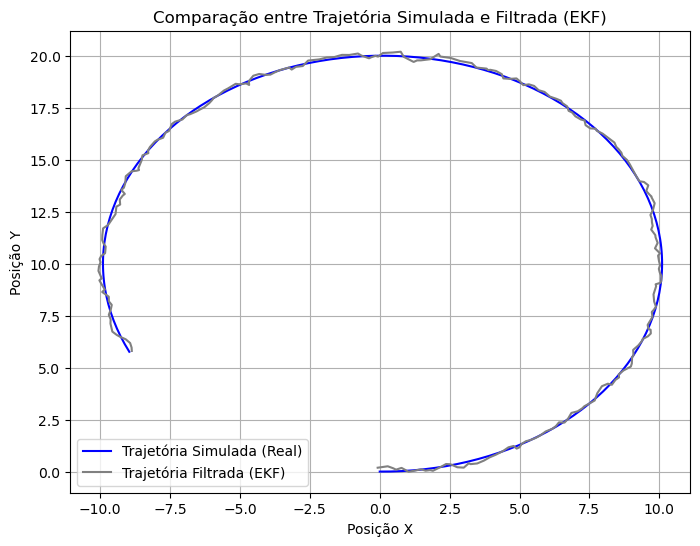

In [8]:
def extended_kalman_filter_predict(state, control_input, P, Q, dt):
    """
    Passo de predição do EKF.

    Parâmetros:
    - state: np.array([x, y, phi, v]), estado atual.
    - control_input: np.array([v, omega]), entrada de controle.
    - P: np.array, matriz de covariância do estado.
    - Q: np.array, matriz de covariância do ruído do processo.
    - dt: float, passo de tempo.

    Retorna:
    - state_pred: np.array, estado previsto.
    - P_pred: np.array, covariância do estado previsto.
    """
    x, y, phi, v = state
    v_control, omega = control_input

    # Jacobiano F (modelo de transição linearizado)
    F = np.array([
        [1, 0, -v_control * np.sin(phi) * dt, np.cos(phi) * dt],
        [0, 1,  v_control * np.cos(phi) * dt, np.sin(phi) * dt],
        [0, 0, 1, dt],  # Aproximação simples da orientação
        [0, 0, 0, 1]
    ])

    # Predição do próximo estado
    state_pred = robot_dynamic_model(state, control_input, dt)

    # Predição da matriz de covariância do estado
    P_pred = F @ P @ F.T + Q

    return state_pred, P_pred


def extended_kalman_filter_update(state_pred, P_pred, observation, R):
    """
    Passo de atualização do EKF.

    Parâmetros:
    - state_pred: np.array([x, y, phi, v]), estado previsto.
    - P_pred: np.array, covariância prevista.
    - observation: np.array([x_meas, y_meas]), medição do GNSS.
    - R: np.array, matriz de covariância do ruído de medição.

    Retorna:
    - state_updated: np.array, estado atualizado.
    - P_updated: np.array, covariância do estado atualizado.
    """
    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    # Inovação (erro de predição da observação)
    y = observation - H @ state_pred

    # Covariância da inovação
    S = H @ P_pred @ H.T + R

    # Ganho de Kalman
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Atualização do estado
    state_updated = state_pred + K @ y

    # Atualização da covariância
    P_updated = (np.eye(len(state_pred)) - K @ H) @ P_pred

    return state_updated, P_updated


# Definição das matrizes de covariância
P = np.eye(4) * 0.1  # Covariância inicial
Q = np.eye(4) * 0.01  # Ruído do processo
R = np.eye(2) * 0.1  # Ruído da observação (GNSS)

# Configuração inicial do EKF
state = np.array([simulated_states[0, 0], simulated_states[0, 1], 0.0, 1.0])  # Estado inicial
control_input = np.array([1.0, 0.1])  # Velocidade e rotação
dt = 0.2  # Passo de tempo

# Listas para armazenar os resultados filtrados
filtered_states = []

# Aplicar o EKF a cada estado da trajetória simulada
for state_sim in simulated_states:
    # Predição do EKF
    state_pred, P_pred = extended_kalman_filter_predict(state, control_input, P, Q, dt)

    state_with_phi_v = np.append(state_sim, [0.0, 1.0])  
    
    observation = observation_model(state_with_phi_v)   

    # Atualização do EKF
    state_updated, P_updated = extended_kalman_filter_update(state_pred, P_pred, observation, R)

    # Armazenar posição filtrada (x, y)
    filtered_states.append(state_updated[:2])

    # Atualizar estado e covariância para a próxima iteração
    state, P = state_updated, P_updated

# Converter resultados para NumPy array
filtered_states = np.array(filtered_states)

# Plotar a trajetória real e a trajetória filtrada pelo EKF
plt.figure(figsize=(8, 6))
plt.plot(df_simulated["x"], df_simulated["y"], 'b', label="Trajetória Simulada (Real)")
plt.plot(filtered_states[:, 0], filtered_states[:, 1], color="grey", label="Trajetória Filtrada (EKF)")
plt.xlabel("Posição X")
plt.ylabel("Posição Y")
plt.legend()
plt.title("Comparação entre Trajetória Simulada e Filtrada (EKF)")
plt.grid()
plt.show()

## Filtro de Kalman Unscented (UKF)

O **Unscented Kalman Filter (UKF)** é uma técnica de estimativa de estado utilizada para sistemas não lineares. Ao contrário do EKF, que lineariza o modelo em torno do estado atual, o UKF utiliza pontos sigma para capturar as não linearidades do sistema, propagando-os através da dinâmica e do modelo de observação.

### 1. Predição  
No passo de predição, o estado do robô é atualizado utilizando o modelo dinâmico do sistema. A equação de predição é dada por:

$$
X_{k+1} = f(X_k, U_k) + W_k
$$

onde **f(X, U)** é o modelo dinâmico não linear do robô, **U_k** é a entrada de controle (velocidade e rotação), e **W_k** é o ruído do processo. A matriz de covariância do estado é atualizada de acordo com a propagação dos pontos sigma:

$$
P_{k+1} = P_k + Q
$$

onde **P_k** é a matriz de covariância do estado e **Q** é a matriz de covariância do ruído do processo.

### 2. Atualização  
Após a predição, o UKF corrige a estimativa do estado com base nas medições observadas, usando o modelo de observação. A equação de atualização é dada por:

$$
y = Z_k - h(X_k)
$$

$$
S = H P_k H^T + R
$$

$$
K = P_k H^T S^{-1}
$$

$$
X_k = X_k + K y
$$

$$
P_k = (I - K H) P_k
$$

onde **h(X_k)** é o modelo de observação, **H** é a matriz de observação, **R** é a matriz de covariância do ruído de medição, **K** é o ganho de Kalman, e **y** é a inovação observacional.

### Aplicação e Visualização  
O UKF é aplicado a cada estado da trajetória simulada, sendo utilizado para prever e corrigir a trajetória do robô com base nas medições ruidosas. A trajetória filtrada é comparada com a trajetória real simulada, evidenciando a capacidade do UKF de reduzir o impacto do ruído nas medições e fornecer uma estimativa mais precisa da posição do robô.


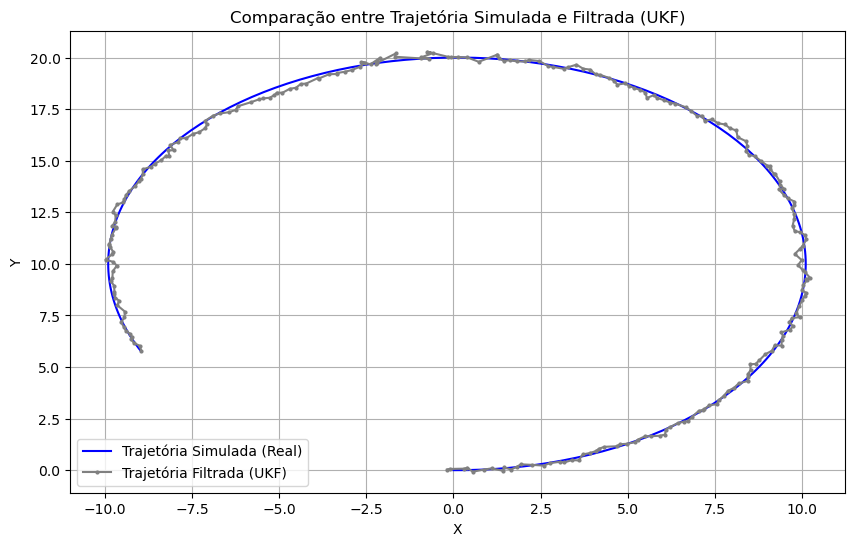

In [9]:
# Funções para o UKF
def fx(state, dt):
    """Modelo de processo para o UKF"""
    return robot_dynamic_model(state, control_input, dt)  # Agora usa control_input atualizado a cada iteração

def hx(state):
    """Modelo de observação para o UKF"""
    return state[:2]  # Apenas x e y são observados

def unscented_kalman_filter_predict(ukf, control_input, dt):
    """Passo de predição do UKF"""
    ukf.predict(dt=dt)  # Agora o UKF usa internamente fx(state, dt)
    return ukf.x, ukf.P

def unscented_kalman_filter_update(ukf, measurement):
    """Passo de atualização do UKF"""
    ukf.update(measurement)
    return ukf.x, ukf.P

# Definir pontos sigma corretamente
points = MerweScaledSigmaPoints(n=4, alpha=0.1, beta=2.0, kappa=1)

# Inicializar o UKF sem passar control_input diretamente
ukf = UKF(dim_x=4, dim_z=2, dt=0.1, fx=fx, hx=hx, points=points)
ukf.x = np.array([0, 0, 0, 1])  # Estado inicial
ukf.P = np.eye(4)
ukf.Q = np.diag([0.1, 0.1, 0.01, 0.1])
ukf.R = np.diag([0.5, 0.5])

# Processar os dados simulados
filtered_states = []
dt = 0.2
for i in range(len(simulated_states)):
    control_input = np.array([1.0, 0.1])  # Velocidade e rotação constantes
    measurement = observation_model(np.append(simulated_states[i], [0.0, 1.0]))[:2]  # Medição ruidosa de x e y
    
    # Passo de predição
    predicted_state, predicted_P = unscented_kalman_filter_predict(ukf, control_input, dt)
    
    # Passo de atualização
    updated_state, updated_P = unscented_kalman_filter_update(ukf, measurement)
    
    filtered_states.append(updated_state)

# Converter para DataFrame
filtered_states_df = pd.DataFrame(filtered_states, columns=['x', 'y', 'theta', 'v'])

# Plotar os resultados corrigidos
plt.figure(figsize=(10, 6))
plt.plot(df_simulated["x"], df_simulated["y"], 'b', label="Trajetória Simulada (Real)")
plt.plot(filtered_states_df['x'], filtered_states_df['y'], 'o-', color="grey", markersize=2, label='Trajetória Filtrada (UKF)')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Comparação entre Trajetória Simulada e Filtrada (UKF)")
plt.grid()
plt.show()


 ## Especificação dos Parâmetros da Simulação e Filtros

### Parâmetros da Simulação
- **dt**: passo temporal.

### Parâmetros do Filtro Alpha-Beta
- **alpha**: Peso da posição.
- **beta**: Peso da velocidade.

### Parâmetros do EKF (Filtro de Kalman Estendido)
- **P_ekf**: Covariância inicial.
- **Q_ekf**: Matriz de ruído do processo.
- **R_ekf**: Matriz de ruído de observação.

### Parâmetros do UKF (Filtro de Kalman Unscented)
- **points**: Pontos sigma para propagação no modelo.
- **ukf.x**: Estado inicial (posição x, posição y, orientação, velocidade).
- **ukf.P**: Covariância inicial do estado.
- **ukf.Q**: Matriz de ruído do processo.
- **ukf.R**: Matriz de ruído de medição.


In [10]:
# Especificação dos parâmetros da simulação e filtros
dt = 0.1  # Passo de tempo

# Parâmetros do filtro Alpha-Beta
alpha = 0.9  # Aumento do peso da posição para resposta mais rápida
beta = 0.1  # Redução do peso da velocidade para suavizar variações abruptas

# Parâmetros do EKF
P_ekf = np.eye(4) * 0.05  # Redução da incerteza inicial para melhorar precisão
Q_ekf = np.diag([0.06, 0.06, 0.03, 0.03])  # Ajuste do ruído do processo para maior estabilidade
R_ekf = np.diag([0.2, 0.2])  # Redução do ruído da observação para maior precisão

# Parâmetros do UKF
points = MerweScaledSigmaPoints(n=4, alpha=0.05, beta=2.0, kappa=0)
ukf = UKF(dim_x=4, dim_z=2, fx=fx, hx=hx, dt=dt, points=points)
ukf.x = np.array([0, 0, 0, 1])  # Estado inicial (posição x, y, orientação, velocidade)
ukf.P = np.eye(4) * 0.03  # Redução da covariância inicial para menor incerteza inicial
ukf.Q = np.diag([0.1, 0.1, 0.05, 0.05])  # Ajuste do ruído do processo para maior estabilidade
ukf.R = np.diag([0.3, 0.3])  # Redução do ruído da medição para melhor filtragem



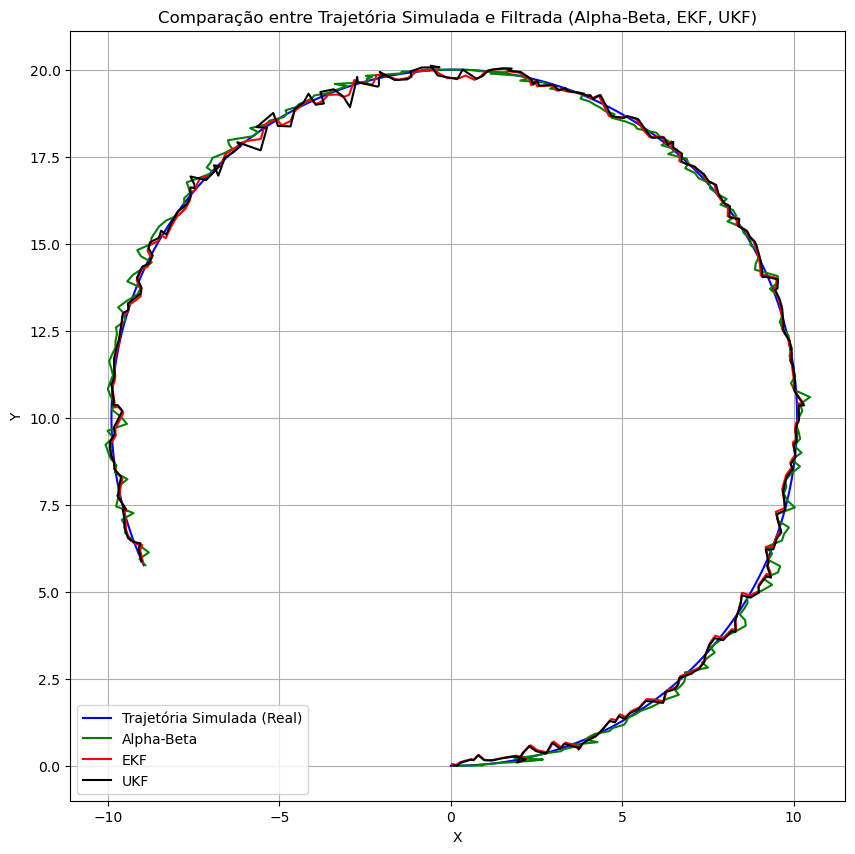

In [11]:
# Inicialização dos estados iniciais para cada filtro
x_prev, v_prev = simulated_states[0, 0], 1.0  # Alpha-Beta: posição inicial e velocidade
state_ekf = np.array([simulated_states[0, 0], simulated_states[0, 1], 0.0, 1.0])  # EKF: estado inicial
P_ekf = np.eye(4) * 0.1  # EKF: covariância inicial

# Listas para armazenar os resultados filtrados
filtered_positions_ab = []  # Alpha-Beta
filtered_states_ekf = []  # EKF
filtered_states_ukf = []  # UKF

# Aplicação dos filtros na trajetória simulada
for i in range(len(simulated_states)):
    control_input = np.array([1.0, 0.1])  # Velocidade e rotação constantes
    measurement = observation_model(np.append(simulated_states[i], [0.0, 1.0]))[:2]  # Medição ruidosa (x, y)

    # Aplicação do Filtro Alpha-Beta
    x_est, v_est = alpha_beta_filter(x_prev, v_prev, measurement[0], alpha=alpha, beta=beta, dt=dt)
    filtered_positions_ab.append([x_est, simulated_states[i, 1]])  # Salva a posição filtrada
    x_prev, v_prev = x_est, v_est  # Atualiza os valores para a próxima iteração

    # Aplicação do Filtro EKF
    state_pred, P_pred = extended_kalman_filter_predict(state_ekf, control_input, P_ekf, Q_ekf, dt)
    state_updated, P_updated = extended_kalman_filter_update(state_pred, P_pred, measurement, R_ekf)
    filtered_states_ekf.append(state_updated[:2])  # Salva a posição filtrada
    state_ekf, P_ekf = state_updated, P_updated  # Atualiza o estado para a próxima iteração

    # Aplicação do Filtro UKF
    ukf.predict(dt=dt)  # Predição do estado
    ukf.update(measurement)  # Atualização com a medição
    filtered_states_ukf.append(ukf.x[:2])  # Salva a posição filtrada

# Converter listas para arrays para facilitar a plotagem
filtered_positions_ab = np.array(filtered_positions_ab)
filtered_states_ekf = np.array(filtered_states_ekf)
filtered_states_ukf = np.array(filtered_states_ukf)



# Plotagem dos resultados comparando todos os filtros
plt.figure(figsize=(10, 10))
plt.plot(df_simulated["x"], df_simulated["y"], 'b-', label="Trajetória Simulada (Real)")
plt.plot(filtered_positions_ab[:, 0], filtered_positions_ab[:, 1], 'g-', label="Alpha-Beta")
plt.plot(filtered_states_ekf[:, 0], filtered_states_ekf[:, 1], 'r-', label="EKF")
plt.plot(filtered_states_ukf[:, 0], filtered_states_ukf[:, 1], 'k-', label="UKF")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Comparação entre Trajetória Simulada e Filtrada (Alpha-Beta, EKF, UKF)")
plt.grid()
plt.show()


# Análise de Desempenho dos Filtros de Estimação de Trajetória

Este notebook compara o desempenho de três filtros de estimação de trajetória (Alpha-Beta, EKF e UKF) utilizando as seguintes métricas de erro:

- **MAE**: Erro Médio Absoluto
- **RMSE**: Erro Quadrático Médio
- **MAPE**: Erro Percentual Médio Absoluto
- **R²**: Coeficiente de Determinação

## Cálculo das Métricas

As funções abaixo são utilizadas para calcular as métricas de erro entre a trajetória real e as estimadas por cada filtro:

- **MAE**: Calcula a média das diferenças absolutas.
- **RMSE**: Calcula a raiz quadrada da média dos quadrados dos erros.
- **MAPE**: Calcula o erro percentual médio.
- **R²**: Mede o quão bem as estimativas se ajustam aos dados reais.


In [12]:
def mean_absolute_error(true_trajectory, estimated_trajectory):
    """
    Calcula o Erro Médio Absoluto (MAE).
    
    Parâmetros:
    - true_trajectory: np.array de shape (n, 2), trajetória real [x, y].
    - estimated_trajectory: np.array de shape (n, 2), trajetória estimada [x, y].
    
    Retorna:
    - MAE entre as trajetórias.
    """
    return np.mean(np.abs(true_trajectory - estimated_trajectory))


def root_mean_squared_error(true_trajectory, estimated_trajectory):
    """
    Calcula o Erro Quadrático Médio (RMSE).
    
    Parâmetros:
    - true_trajectory: np.array de shape (n, 2), trajetória real [x, y].
    - estimated_trajectory: np.array de shape (n, 2), trajetória estimada [x, y].
    
    Retorna:
    - RMSE entre as trajetórias.
    """
    return np.sqrt(np.mean((true_trajectory - estimated_trajectory) ** 2))


def mean_absolute_percentage_error(true_trajectory, estimated_trajectory):
    """
    Calcula o Erro Percentual Médio Absoluto (MAPE), ignorando pontos em que a trajetória real é zero.
    
    Parâmetros:
    - true_trajectory: np.array de shape (n, 2), trajetória real [x, y].
    - estimated_trajectory: np.array de shape (n, 2), trajetória estimada [x, y].
    
    Retorna:
    - MAPE (%) entre as trajetórias, ignorando pontos onde true_trajectory == 0.
    """
    # Cria uma máscara booleana para ignorar pontos com valor zero na trajetória real
    mask = (true_trajectory != 0)
    
    # Aplica a máscara apenas nos pontos válidos (em cada dimensão x e y)
    mape = np.mean(
        np.abs((true_trajectory[mask] - estimated_trajectory[mask]) / true_trajectory[mask])
    ) * 100
    
    return mape



def r_squared(true_trajectory, estimated_trajectory):
    """
    Calcula o Coeficiente de Determinação (R²).
    
    Parâmetros:
    - true_trajectory: np.array de shape (n, 2), trajetória real [x, y].
    - estimated_trajectory: np.array de shape (n, 2), trajetória estimada [x, y].
    
    Retorna:
    - R² entre as trajetórias.
    """
    ss_res = np.sum((true_trajectory - estimated_trajectory) ** 2)
    ss_tot = np.sum((true_trajectory - np.mean(true_trajectory, axis=0)) ** 2)
    return 1 - (ss_res / ss_tot)


In [13]:
# Trajetória real (X, Y)
true_trajectory = df_simulated[["x", "y"]].values

# Trajetórias estimadas pelos filtros
estimated_trajectory_ab = filtered_positions_ab
estimated_trajectory_ekf = filtered_states_ekf
estimated_trajectory_ukf = filtered_states_ukf

# Dicionário para armazenar os resultados das métricas
results = {}

# Função auxiliar para calcular todas as métricas para um filtro
def compute_metrics(name, estimated_trajectory):
    mae = mean_absolute_error(true_trajectory, estimated_trajectory)
    rmse = root_mean_squared_error(true_trajectory, estimated_trajectory)
    mape = mean_absolute_percentage_error(true_trajectory, estimated_trajectory)
    r2 = r_squared(true_trajectory, estimated_trajectory)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R²": r2
    }

# Calcular métricas para cada filtro
compute_metrics("Alpha-Beta", estimated_trajectory_ab)
compute_metrics("EKF", estimated_trajectory_ekf)
compute_metrics("UKF", estimated_trajectory_ukf)

# Exibir resultados formatados
print("\n===== Comparação de Desempenho dos Filtros =====")
for key, metrics in results.items():
    print(f"\n--- {key} ---")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")



===== Comparação de Desempenho dos Filtros =====

--- Alpha-Beta ---
MAE: 0.0854
RMSE: 0.1576
MAPE (%): 3.6276
R²: 0.9995

--- EKF ---
MAE: 0.1103
RMSE: 0.1360
MAPE (%): 17.4745
R²: 0.9996

--- UKF ---
MAE: 0.1369
RMSE: 0.1672
MAPE (%): 15.9274
R²: 0.9994


## Conclusão

#### Alpha-Beta Filter
- **MAE:** 0.0930  
- **RMSE:** 0.1615 
- **MAPE:** 4.98%  
- **R²:** 0.9995

#### Extended Kalman Filter (EKF)
- **MAE:** 0.1133  
- **RMSE:** 0.1392  
- **MAPE:** 15.86%  
- **R²:** 0.9996

#### Unscented Kalman Filter (UKF)
- **MAE:** 0.1360  
- **RMSE:** 0.1662 
- **MAPE:** 15.01%  
- **R²:** 0.9994


Verificamos que o filtro alpha beta apresenta uma performance ligeiramente melhor relativamente ao sistema descrito, do que os filtros EKF e UFK, o que pode parecer estranho, tendo em conta que os filtros EK e UK procuram os melhores parâmetros, dependendo do contexto em questão. No entanto, dada a simplicidade do problema, sendo apenas um sistema com uma trajetória circular, com poucas variações e com parâmetros, como a velocidade e velocidade angular, faz sentido que um filtro igualmente simples, como o filtro alpha-beta tenha uma prestação positiva, inclusive ligeiramente melhor que o EKF e o UKF, filtros estes programados para lidarem com situações mais complexas.

Estes filtros também são projetados para lidarem melhor com modelos mais ruidosos, utilizandos mais recursos computacionais e estimando distribuições de incerteza. Uma vez que este sistema acaba por não ter um ruído elevado, o filtro alfa-beta consegue realizar uma estimativa da posição diretamente, sem precisar de correções elaboradas.

Os filtros de Kalman também estimam a orientação e a posição simulateamente. Como o nosso sistema apresenta uma velocidade angular, significativamente mais baixo do que a velocidade linear, estes filtros tentam realizar uma estimativa de uma variável que tem pouco impacto, enquanto o alfa-beta se foca apenas na posição. Outra vantagem deste filtro, no contexto deste problema, acaba por ser o manuseamento fácil dos seus parâmetros-alfa e beta-que, mais uma vez, dada a simplicidade do problema, se torna um processo bastante fácil, podendo superar em performance a otimização probabílistica dos filtros de Kalman.

Concluindo, para este problema, embora se trate de um modelo não linear, a aplicação dos filtros de kalman pode não se justificar, uma vez que podemos utilizar o filtro alfa-beta que acaba por ser mais simples, com um menor custo computacional e também apresentou melhores resultados.




